First few rows of the dataset:
    Age  Gender  Education Level          Job Title  Years of Experience  \
0  32.0    Male                1  Software Engineer                  5.0   
1  28.0  Female                2       Data Analyst                  3.0   
2  45.0    Male                3            Manager                 15.0   
3  36.0  Female                1    Sales Associate                  7.0   
4  52.0    Male                2           Director                 20.0   

     Salary Country      Race  Senior  
0   90000.0      UK     White       0  
1   65000.0     USA  Hispanic       0  
2  150000.0  Canada     White       1  
3   60000.0     USA  Hispanic       0  
4  200000.0     USA     Asian       0  


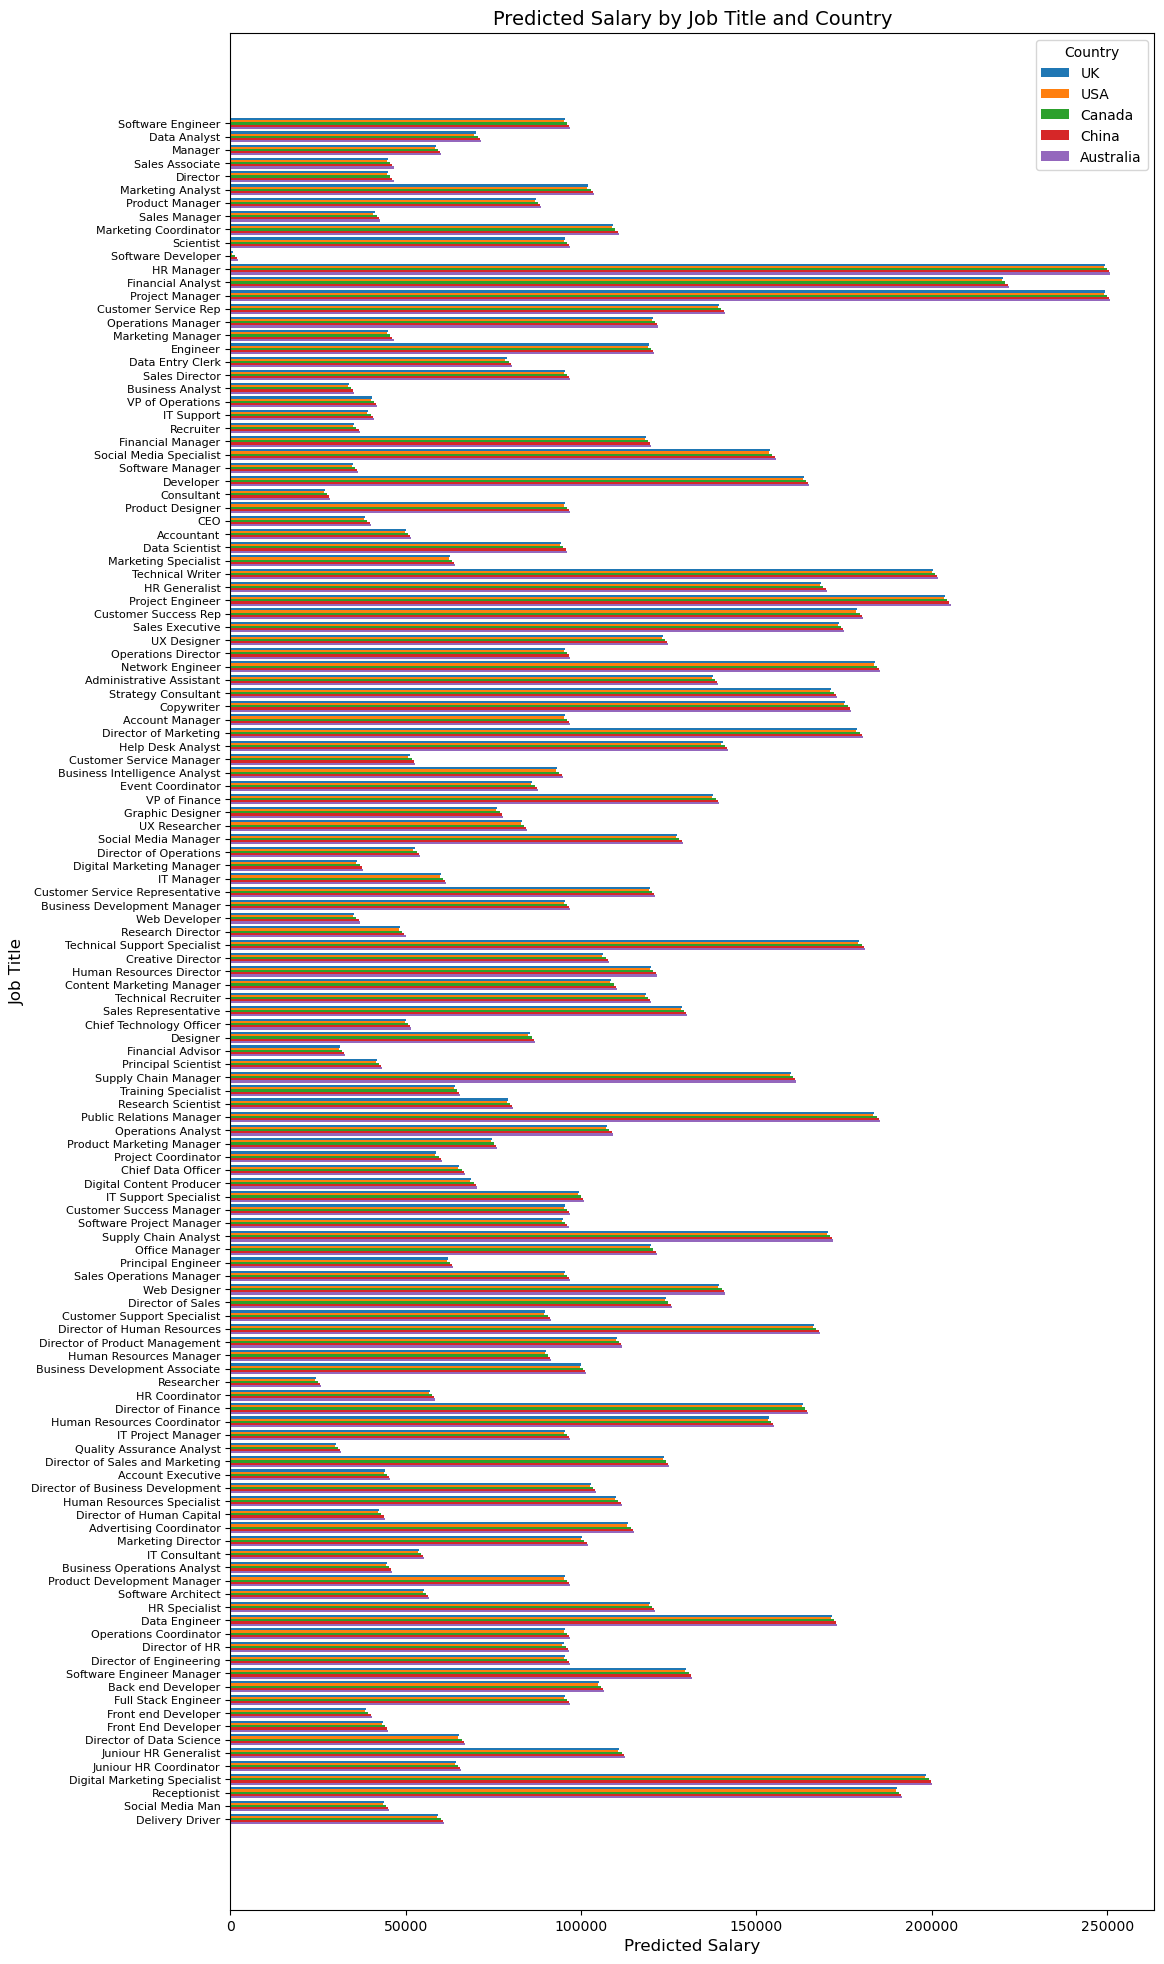

In [32]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import os

# Load the CSV file into a DataFrame
file_name = 'Salary.csv'

if not os.path.isfile(file_name):
    print(f"Error: File '{file_name}' not found. Please ensure it's in the project directory.")
    exit()

df = pd.read_csv(file_name)
print("First few rows of the dataset:")
print(df.head())

# Encode categorical variables (Job Title and Country)
X = df[['Job Title', 'Country']]  # Features (input data)
y = df['Salary']  # Target (output we want to predict)

column_transformer = ColumnTransformer(transformers=[
    ('encoder', OneHotEncoder(drop='first'), ['Job Title', 'Country'])
], remainder='passthrough')

X_encoded = column_transformer.fit_transform(X)

# Train the model
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions for all Job Title-Country combinations
unique_job_titles = df['Job Title'].unique()
unique_countries = df['Country'].unique()

predictions = []

for job in unique_job_titles:
    for country in unique_countries:
        input_data = pd.DataFrame({'Job Title': [job], 'Country': [country]})
        input_encoded = column_transformer.transform(input_data)
        predicted_salary = model.predict(input_encoded)[0]
        predictions.append({'Job Title': job, 'Country': country, 'Predicted Salary': predicted_salary})

# Convert predictions to a DataFrame
predictions_df = pd.DataFrame(predictions)

# Plot the horizontal bar chart
plt.figure(figsize=(12, 20))  # Make it tall for better readability

# Pivot the table to prepare data for plotting
pivot = predictions_df.pivot(index='Job Title', columns='Country', values='Predicted Salary')

# Create a horizontal bar chart for each country
bar_height = 0.8 / len(unique_countries)  # Space bars vertically
job_indices = np.arange(len(unique_job_titles))  # Index for each job title

for idx, country in enumerate(unique_countries):
    plt.barh(job_indices + idx * bar_height, pivot[country], height=bar_height, label=country)

# Customizations for better readability
plt.yticks(job_indices + bar_height * (len(unique_countries) / 2 - 0.5), 
           unique_job_titles, fontsize=8)  # Job titles on the y-axis
plt.xlabel('Predicted Salary', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.title('Predicted Salary by Job Title and Country', fontsize=14)
plt.legend(title='Country', fontsize=10)
plt.gca().invert_yaxis()  # Invert y-axis for better alignment
plt.tight_layout(pad=2)  # Add spacing

# Show the plot
plt.show()


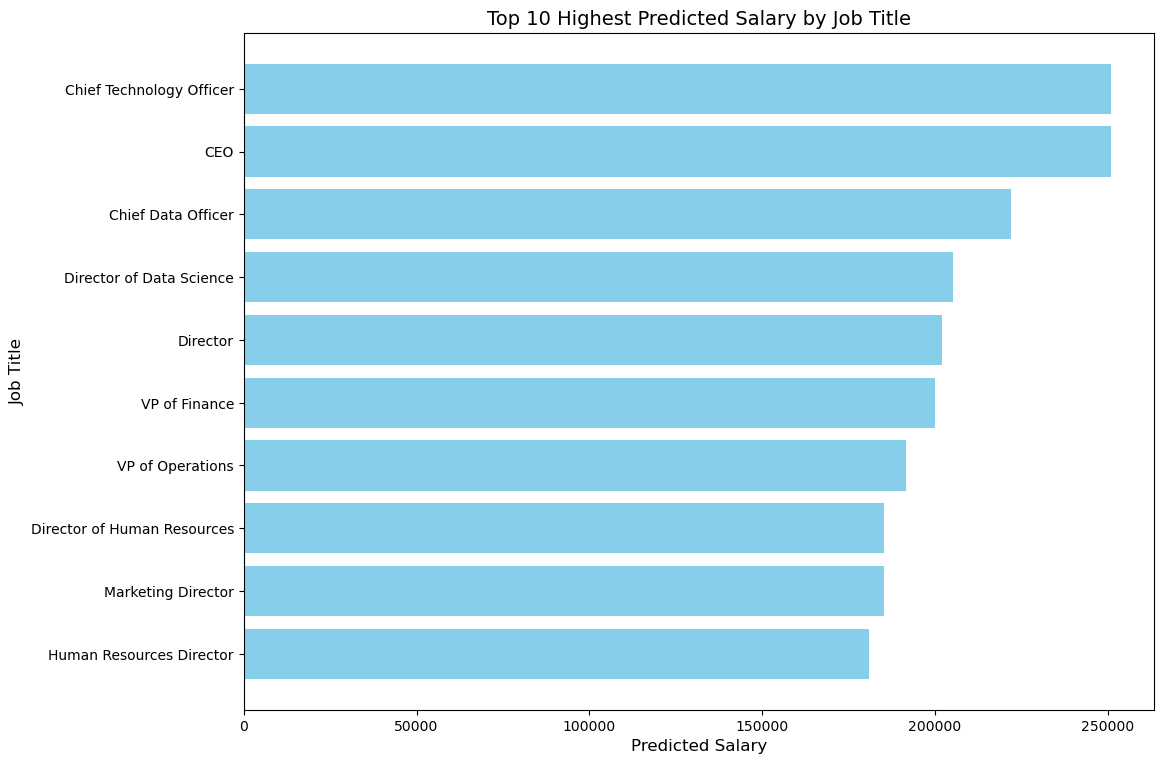

In [33]:
# Sort the predictions by predicted salary in descending order and get the top 10 highest salaries
top_10_predictions = predictions_df.sort_values(by='Predicted Salary', ascending=False).drop_duplicates(subset='Job Title').head(10)

# Plot the top 10 highest predicted salaries by Job Title
plt.figure(figsize=(12, 8))

# Create a horizontal bar chart for the top 10 salaries by Job Title
plt.barh(top_10_predictions['Job Title'], top_10_predictions['Predicted Salary'], color='skyblue')

# Customizations for better readability
plt.xlabel('Predicted Salary', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.title('Top 10 Highest Predicted Salary by Job Title', fontsize=14)
plt.gca().invert_yaxis()  # Invert y-axis for better alignment
plt.tight_layout(pad=2)  # Add spacing

# Show the plot
plt.show()


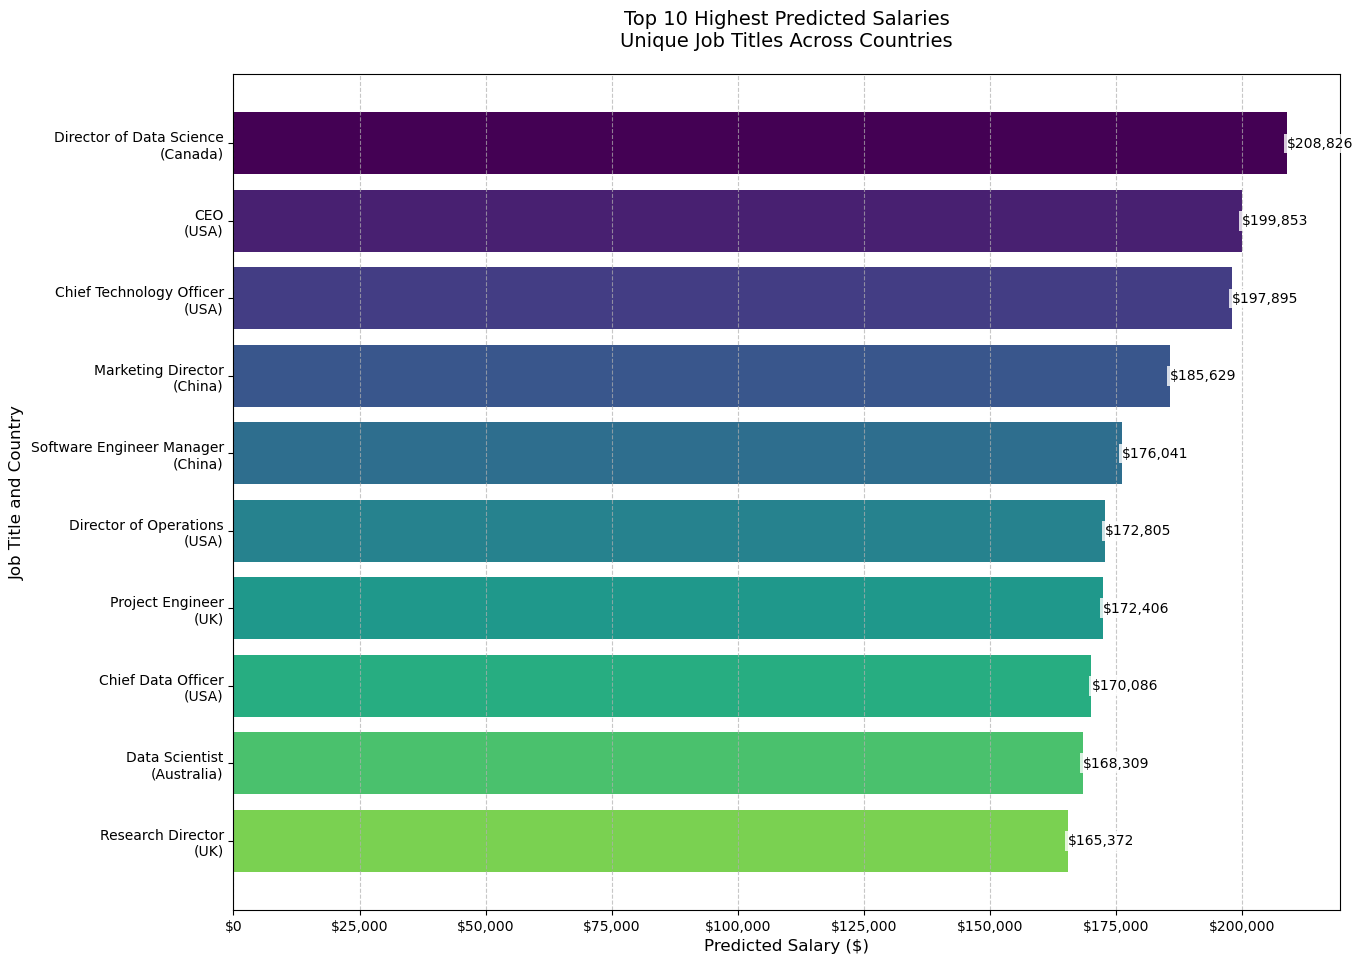


Detailed Top 10 Salary Information:
                Job Title   Country  Predicted Salary
 Director of Data Science    Canada     208826.056623
                      CEO       USA     199853.177267
 Chief Technology Officer       USA     197895.053711
       Marketing Director     China     185629.081474
Software Engineer Manager     China     176041.345165
   Director of Operations       USA     172804.761905
         Project Engineer        UK     172406.054868
       Chief Data Officer       USA     170085.776595
           Data Scientist Australia     168308.523680
        Research Director        UK     165371.624446


In [45]:
# Sort and get unique job titles with highest salaries
all_sorted = predictions_df.sort_values(by='Predicted Salary', ascending=False)

# Initialize lists to keep track of seen jobs
seen_jobs = set()
top_10_rows = []

# Iterate through sorted data to get diverse combinations
for _, row in all_sorted.iterrows():
    job = row['Job Title']
    
    # Only add if we haven't seen this job title before
    if job not in seen_jobs:
        top_10_rows.append(row)
        seen_jobs.add(job)
        
        # Break if we have 10 unique job titles
        if len(top_10_rows) == 10:
            break

# Create DataFrame from selected rows
top_10_predictions = pd.DataFrame(top_10_rows)

# Create figure
plt.figure(figsize=(14, 10))  # Taller figure for better readability

# Create labels combining Job Title and Country
labels = top_10_predictions.apply(lambda x: f"{x['Job Title']}\n({x['Country']})", axis=1)

# Create horizontal bar chart with different colors
colors = plt.cm.viridis(np.linspace(0, 0.8, 10))  # Color gradient from viridis palette
bars = plt.barh(labels, top_10_predictions['Predicted Salary'], color=colors)

# Add value labels on the bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, i, f'${width:,.0f}', 
             ha='left', va='center', fontsize=10,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# Customize the plot
plt.xlabel('Predicted Salary ($)', fontsize=12)
plt.ylabel('Job Title and Country', fontsize=12)
plt.title('Top 10 Highest Predicted Salaries\nUnique Job Titles Across Countries', 
          fontsize=14, pad=20)
plt.gca().invert_yaxis()  # Invert y-axis for better readability

# Format salary values on x-axis with comma separator
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout(pad=2)

# Show the plot
plt.show()

# Print the detailed information
print("\nDetailed Top 10 Salary Information:")
print(top_10_predictions[['Job Title', 'Country', 'Predicted Salary']]
      .sort_values(by='Predicted Salary', ascending=False)
      .to_string(index=False))

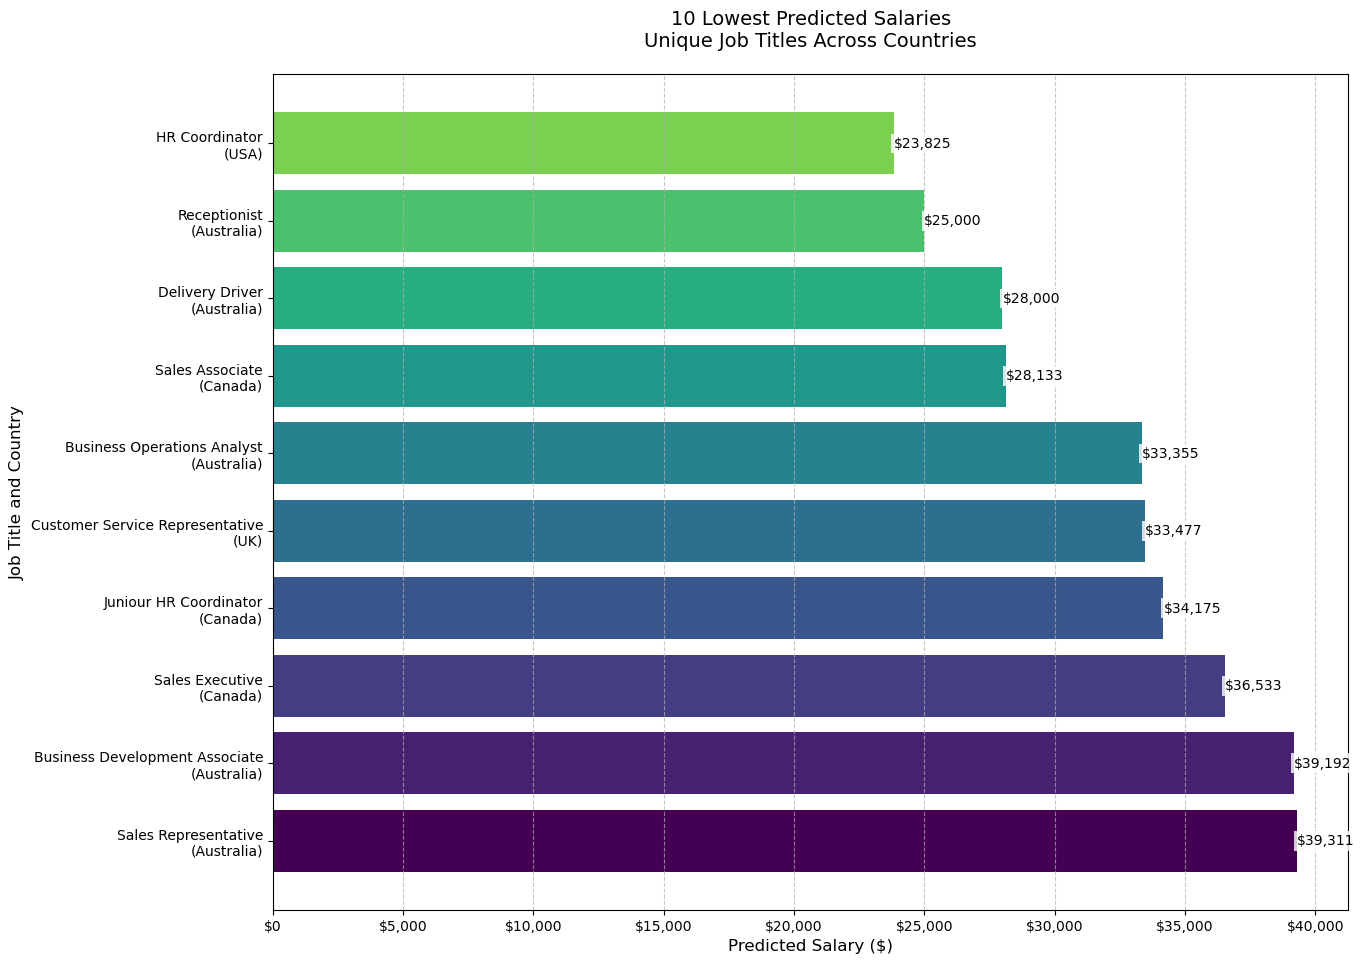


Detailed Bottom 10 Salary Information:
                      Job Title   Country  Predicted Salary
                 HR Coordinator       USA      23825.119048
                   Receptionist Australia      25000.000000
                Delivery Driver Australia      28000.000000
                Sales Associate    Canada      28133.254021
    Business Operations Analyst Australia      33355.182716
Customer Service Representative        UK      33477.380952
         Juniour HR Coordinator    Canada      34174.786730
                Sales Executive    Canada      36533.220252
 Business Development Associate Australia      39192.500000
           Sales Representative Australia      39311.407852


In [46]:
# Sort in ascending order (lowest to highest) and get unique job titles
all_sorted = predictions_df.sort_values(by='Predicted Salary', ascending=True)

# Initialize lists to keep track of seen jobs
seen_jobs = set()
bottom_10_rows = []

# Iterate through sorted data to get diverse combinations
for _, row in all_sorted.iterrows():
    job = row['Job Title']
    
    # Only add if we haven't seen this job title before
    if job not in seen_jobs:
        bottom_10_rows.append(row)
        seen_jobs.add(job)
        
        # Break if we have 10 unique job titles
        if len(bottom_10_rows) == 10:
            break

# Create DataFrame from selected rows
bottom_10_predictions = pd.DataFrame(bottom_10_rows)

# Create figure
plt.figure(figsize=(14, 10))  # Taller figure for better readability

# Create labels combining Job Title and Country
labels = bottom_10_predictions.apply(lambda x: f"{x['Job Title']}\n({x['Country']})", axis=1)

# Create horizontal bar chart with different colors
colors = plt.cm.viridis(np.linspace(0.8, 0, 10))  # Reversed color gradient
bars = plt.barh(labels, bottom_10_predictions['Predicted Salary'], color=colors)

# Add value labels on the bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, i, f'${width:,.0f}', 
             ha='left', va='center', fontsize=10,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# Customize the plot
plt.xlabel('Predicted Salary ($)', fontsize=12)
plt.ylabel('Job Title and Country', fontsize=12)
plt.title('10 Lowest Predicted Salaries\nUnique Job Titles Across Countries', 
          fontsize=14, pad=20)
plt.gca().invert_yaxis()  # Invert y-axis for better readability

# Format salary values on x-axis with comma separator
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout(pad=2)

# Show the plot
plt.show()

# Print the detailed information
print("\nDetailed Bottom 10 Salary Information:")
print(bottom_10_predictions[['Job Title', 'Country', 'Predicted Salary']]
      .sort_values(by='Predicted Salary', ascending=True)
      .to_string(index=False))

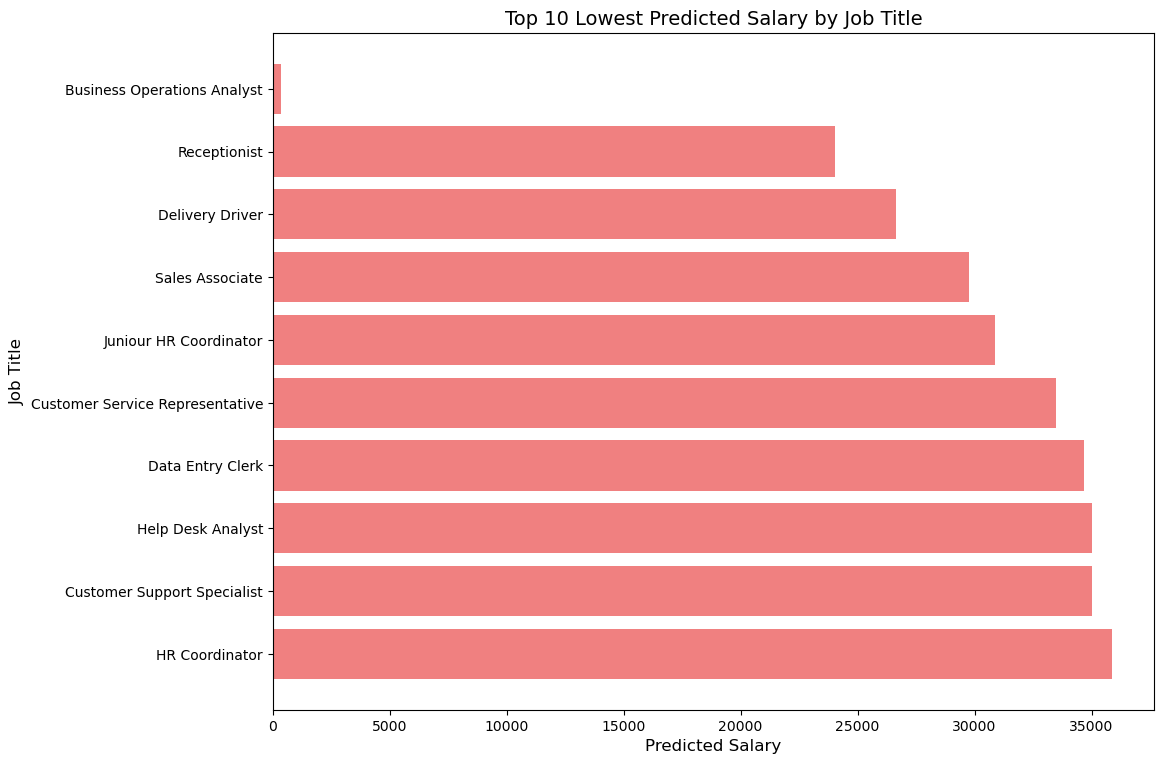

In [35]:
# Sort the predictions by predicted salary in ascending order and get the top 10 lowest salaries
lowest_10_predictions = predictions_df.sort_values(by='Predicted Salary', ascending=True).drop_duplicates(subset='Job Title').head(10)

# Plot the top 10 lowest predicted salaries by Job Title
plt.figure(figsize=(12, 8))

# Create a horizontal bar chart for the lowest 10 salaries by Job Title
plt.barh(lowest_10_predictions['Job Title'], lowest_10_predictions['Predicted Salary'], color='lightcoral')

# Customizations for better readability
plt.xlabel('Predicted Salary', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.title('Top 10 Lowest Predicted Salary by Job Title', fontsize=14)
plt.gca().invert_yaxis()  # Invert y-axis for better alignment
plt.tight_layout(pad=2)  # Add spacing

# Show the plot
plt.show()


In [36]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict salaries for the test set
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)  # Mean Squared Error
r2 = r2_score(y_test, y_pred)  # Accuracy as R-squared value
residuals = y_test - y_pred  # Residuals (errors)
se = np.std(residuals) / np.sqrt(len(y_test))  # Standard Error

# Display metrics
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Accuracy: {r2:.2%}")  # Convert to percentage
print(f"Standard Error (SE): {se:.2f}")


Mean Squared Error (MSE): 1166230933.18
R-squared Accuracy: 58.03%
Standard Error (SE): 933.23


In [37]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)  # y_train should be categorical
y_pred = classifier.predict(X_test)


In [38]:
# Define bins and labels for salary ranges
bins = [0, 50000, 100000, 200000, float('inf')]  # Adjust as needed
labels = ['Low', 'Medium', 'High', 'Very High']

# Categorize the actual target values
y_test_categorical = pd.cut(y_test, bins=bins, labels=labels)

# Categorize the predictions
y_pred_categorical = pd.cut(y_pred, bins=bins, labels=labels)


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test_categorical, y_pred_categorical)
precision = precision_score(y_test_categorical, y_pred_categorical, average='weighted')
recall = recall_score(y_test_categorical, y_pred_categorical, average='weighted')
f1 = f1_score(y_test_categorical, y_pred_categorical, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

print("\nClassification Report:")
print(classification_report(y_test_categorical, y_pred_categorical))



Accuracy: 0.69
Precision: 0.68
Recall: 0.69
F1-Score: 0.68

Classification Report:
              precision    recall  f1-score   support

        High       0.73      0.83      0.78       720
         Low       0.73      0.69      0.71       177
      Medium       0.58      0.47      0.52       416
   Very High       0.50      0.21      0.29        24

    accuracy                           0.69      1337
   macro avg       0.63      0.55      0.57      1337
weighted avg       0.68      0.69      0.68      1337



In [40]:
# Define salary ranges and categorize into classes
def classify_salary(salary):
    if salary >= 100000:
        return 'Very High'
    elif salary >= 70000:
        return 'High'
    elif salary >= 40000:
        return 'Medium'
    else:
        return 'Low'

# Apply the classification to the 'Predicted Salary' column
df['Class'] = df['Salary'].apply(classify_salary)

# Count the number of occurrences for each class
class_counts = df['Class'].value_counts()

# Display the counts
print("Number of data points for each class:")
print(class_counts)


Number of data points for each class:
Class
Very High    3941
Medium       1163
High         1117
Low           463
Name: count, dtype: int64


First few rows of the dataset:
    Age  Gender  Education Level          Job Title  Years of Experience  \
0  32.0    Male                1  Software Engineer                  5.0   
1  28.0  Female                2       Data Analyst                  3.0   
2  45.0    Male                3            Manager                 15.0   
3  36.0  Female                1    Sales Associate                  7.0   
4  52.0    Male                2           Director                 20.0   

     Salary Country      Race  Senior  
0   90000.0      UK     White       0  
1   65000.0     USA  Hispanic       0  
2  150000.0  Canada     White       1  
3   60000.0     USA  Hispanic       0  
4  200000.0     USA     Asian       0  
Mean Squared Error (MSE): 1206682709.50
R-squared Accuracy: 56.58%


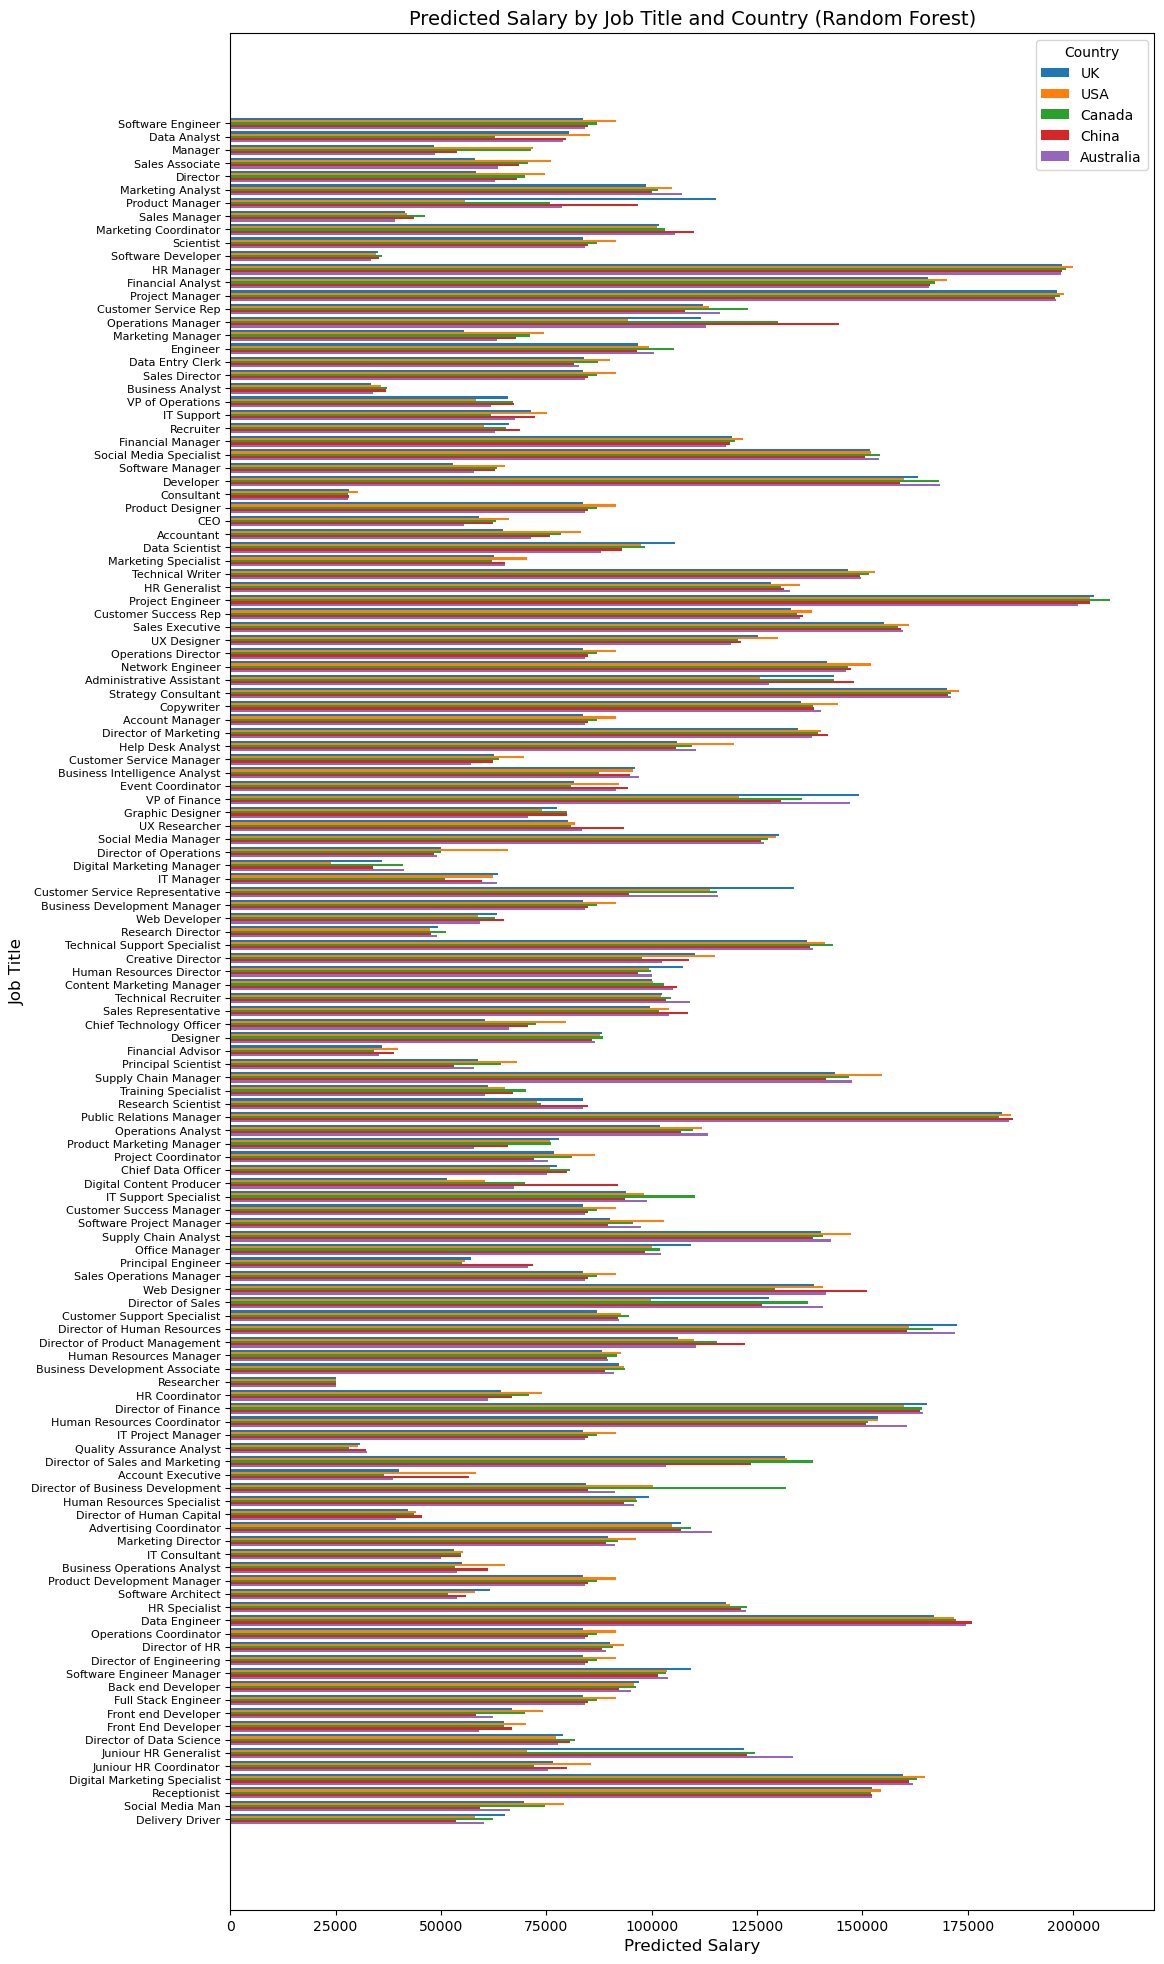

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Load the CSV file into a DataFrame
file_name = 'Salary.csv'

if not os.path.isfile(file_name):
    print(f"Error: File '{file_name}' not found. Please ensure it's in the project directory.")
    exit()

df = pd.read_csv(file_name)
print("First few rows of the dataset:")
print(df.head())

# Encode categorical variables (Job Title and Country)
X = df[['Job Title', 'Country']]  # Features (input data)
y = df['Salary']  # Target (output we want to predict)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

column_transformer = ColumnTransformer(transformers=[
    ('encoder', OneHotEncoder(drop='first'), ['Job Title', 'Country'])
], remainder='passthrough')

X_encoded = column_transformer.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Accuracy: {r2 * 100:.2f}%")

# Generate predictions for all Job Title-Country combinations
unique_job_titles = df['Job Title'].unique()
unique_countries = df['Country'].unique()

predictions = []

for job in unique_job_titles:
    for country in unique_countries:
        input_data = pd.DataFrame({'Job Title': [job], 'Country': [country]})
        input_encoded = column_transformer.transform(input_data)
        predicted_salary = model.predict(input_encoded)[0]
        predictions.append({'Job Title': job, 'Country': country, 'Predicted Salary': predicted_salary})

# Convert predictions to a DataFrame
predictions_df = pd.DataFrame(predictions)

# Plot the horizontal bar chart
plt.figure(figsize=(12, 20))  # Make it tall for better readability

# Pivot the table to prepare data for plotting
pivot = predictions_df.pivot(index='Job Title', columns='Country', values='Predicted Salary')

# Create a horizontal bar chart for each country
bar_height = 0.8 / len(unique_countries)  # Space bars vertically
job_indices = np.arange(len(unique_job_titles))  # Index for each job title

for idx, country in enumerate(unique_countries):
    plt.barh(job_indices + idx * bar_height, pivot[country], height=bar_height, label=country)

# Customizations for better readability
plt.yticks(job_indices + bar_height * (len(unique_countries) / 2 - 0.5), 
           unique_job_titles, fontsize=8)  # Job titles on the y-axis
plt.xlabel('Predicted Salary', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.title('Predicted Salary by Job Title and Country (Random Forest)', fontsize=14)
plt.legend(title='Country', fontsize=10)
plt.gca().invert_yaxis()  # Invert y-axis for better alignment
plt.tight_layout(pad=2)  # Add spacing

# Show the plot
plt.show()


In [42]:
# Predict on the test set
rf_y_pred = rf_model.predict(X_test)  # Assuming `rf_model` is your trained Random Forest model

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")

# Precision
rf_precision = precision_score(y_test, rf_y_pred, average='weighted')
print(f"Random Forest Precision: {rf_precision:.2f}")

# Recall
rf_recall = recall_score(y_test, rf_y_pred, average='weighted')
print(f"Random Forest Recall: {rf_recall:.2f}")

# F1 Score
rf_f1 = f1_score(y_test, rf_y_pred, average='weighted')
print(f"Random Forest F1 Score: {rf_f1:.2f}")

# Classification Report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))


NameError: name 'rf_model' is not defined

Epoch 1/50


c:\Users\lenov\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8420 - mae: 0.7852 - val_loss: 0.4357 - val_mae: 0.5304
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4641 - mae: 0.5434 - val_loss: 0.3987 - val_mae: 0.4860
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4139 - mae: 0.4986 - val_loss: 0.4058 - val_mae: 0.4909
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4145 - mae: 0.4972 - val_loss: 0.3911 - val_mae: 0.4797
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4123 - mae: 0.4964 - val_loss: 0.3942 - val_mae: 0.4817
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3956 - mae: 0.4838 - val_loss: 0.3936 - val_mae: 0.4784
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3938 - mae: 0.4826 - val_loss: 0.3931 - val_mae: 0.4798
Epoch 8/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3969 - mae: 0.4845 - val_loss: 0.4024 - val_mae: 0.4862
Epoch 9/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4087 

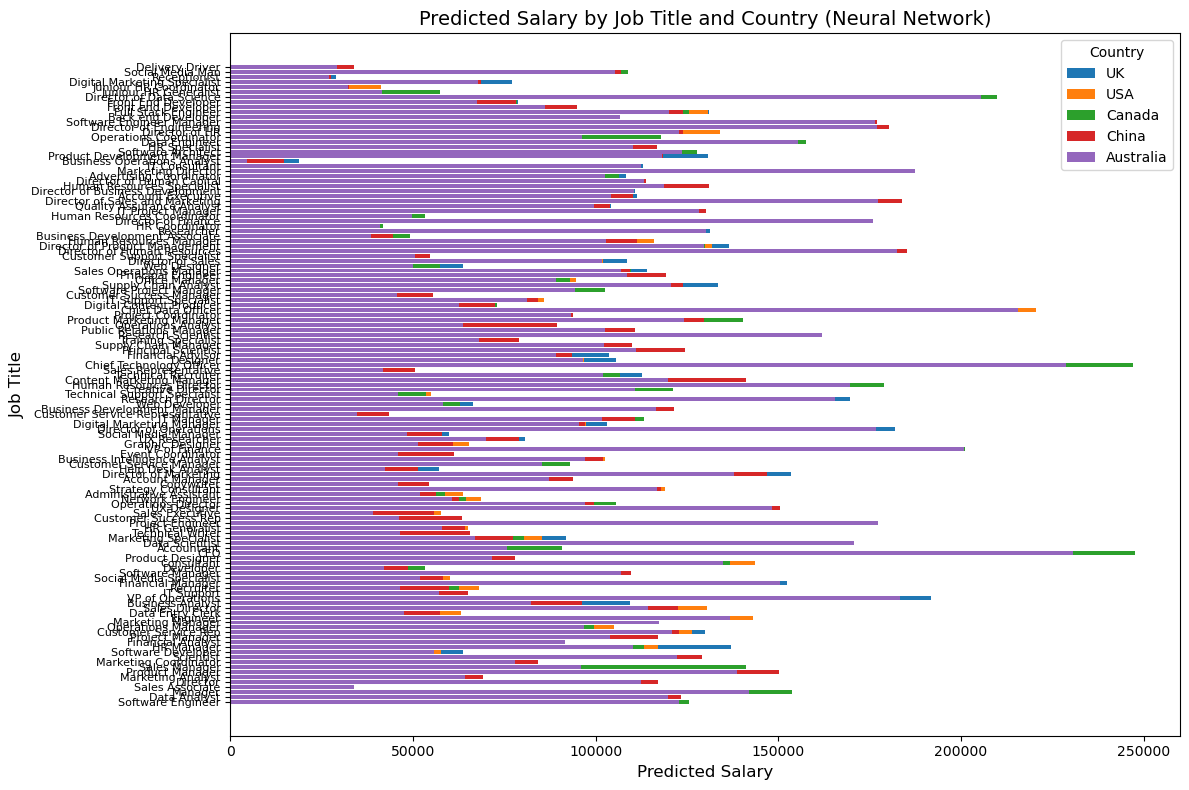

In [30]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Load dataset
file_name = 'Salary.csv'
df = pd.read_csv(file_name)

# Features (Job Title and Country) and Target (Salary)
X = df[['Job Title', 'Country']]
y = df['Salary']

# Encode categorical features
encoder = OneHotEncoder(drop='first')
X_encoded = encoder.fit_transform(X).toarray()

# Standardize the target variable
scaler = StandardScaler()
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_scaled, test_size=0.2, random_state=42)

# Build the neural network
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)  # Single output for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)

# Evaluate the model
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MAE: {test_mae:.2f}")

# Generate predictions for the grid
job_titles = df['Job Title'].unique()
countries = df['Country'].unique()

# Create grid data for all combinations of job titles and countries
grid_data = []
for job in job_titles:
    for country in countries:
        grid_data.append({'Job Title': job, 'Country': country})
grid_df = pd.DataFrame(grid_data)

# Encode grid data
grid_encoded = encoder.transform(grid_df).toarray()

# Predict salaries for the grid
predicted_salaries = model.predict(grid_encoded)
predicted_salaries = scaler.inverse_transform(predicted_salaries)  # Convert back to original scale
grid_df['Predicted Salary'] = predicted_salaries.ravel()

# Plot predictions
plt.figure(figsize=(12, 8))
for idx, country in enumerate(countries):
    subset = grid_df[grid_df['Country'] == country]
    plt.barh(subset['Job Title'], subset['Predicted Salary'], label=country)

# Customize the axis labels and title
plt.xlabel('Predicted Salary', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.title('Predicted Salary by Job Title and Country (Neural Network)', fontsize=14)

# Make job titles smaller
plt.yticks(fontsize=8)
plt.legend(title='Country')
plt.tight_layout()
plt.show()


Epoch 1/100


c:\Users\lenov\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.4395 - mae: 0.9557 - val_loss: 0.8877 - val_mae: 0.8029 - learning_rate: 0.0010
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7396 - mae: 0.6957 - val_loss: 0.7471 - val_mae: 0.7341 - learning_rate: 0.0010
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6540 - mae: 0.6536 - val_loss: 0.5423 - val_mae: 0.6159 - learning_rate: 0.0010
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5906 - mae: 0.6176 - val_loss: 0.4197 - val_mae: 0.5239 - learning_rate: 0.0010
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5569 - mae: 0.5978 - val_loss: 0.4092 - val_mae: 0.4999 - learning_rate: 0.0010
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5238 - mae: 0.5769 - val_loss: 0.4061 - val_mae: 0.4943 - learning_rate: 0.0010
Epoch 7/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5227 - mae: 0.5824 - val_loss: 0.4114 - val_mae: 0.4942 - learning_rate: 0.0010
Epoch 8/100

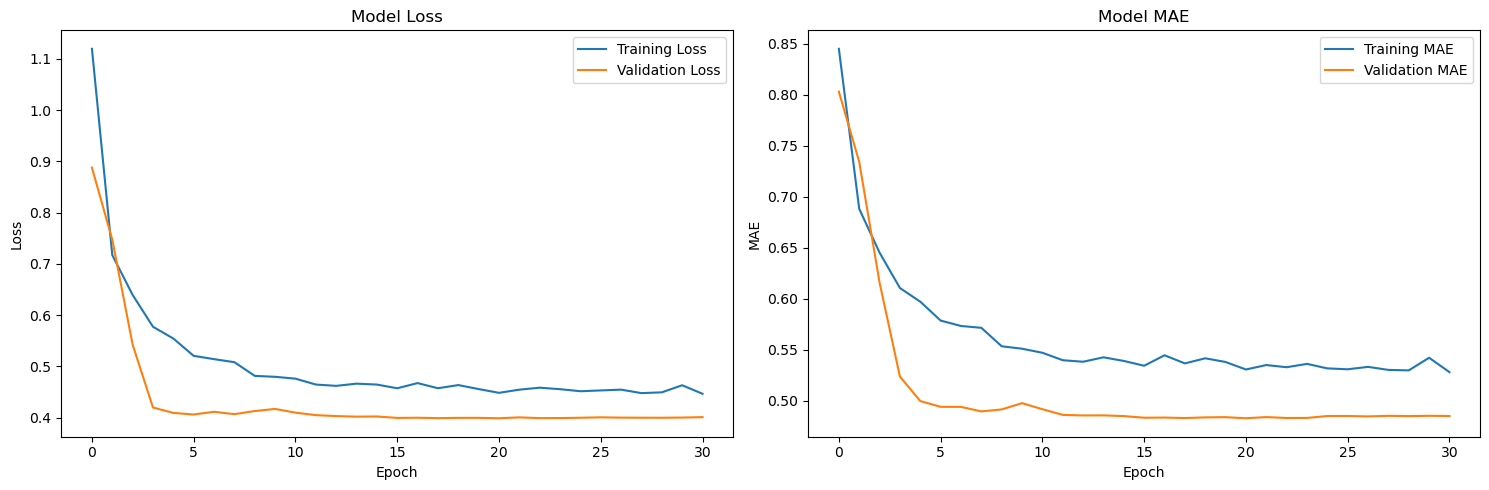

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


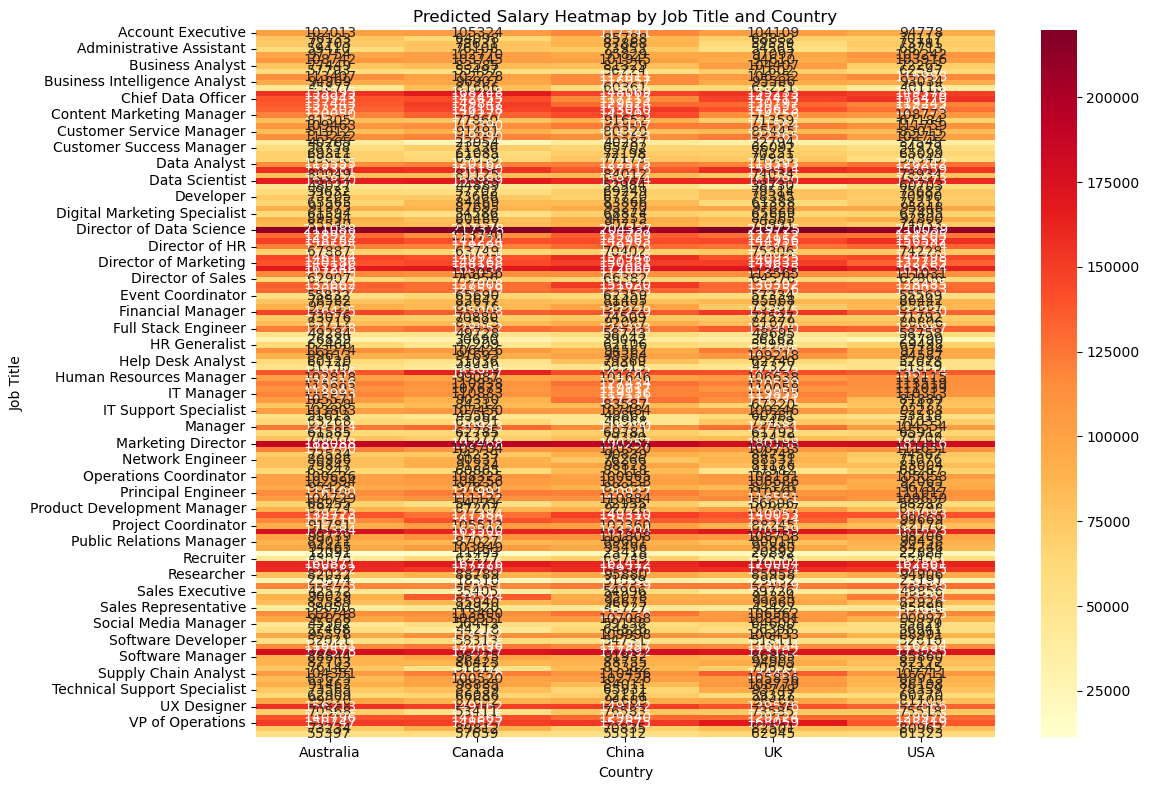

In [27]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def load_and_preprocess_data(file_name):
    """Load and preprocess the dataset"""
    df = pd.read_csv(file_name)
    
    # Remove outliers using IQR method
    Q1 = df['Salary'].quantile(0.25)
    Q3 = df['Salary'].quantile(0.75)
    IQR = Q3 - Q1
    df = df[~((df['Salary'] < (Q1 - 1.5 * IQR)) | (df['Salary'] > (Q3 + 1.5 * IQR)))]
    
    return df

def prepare_features(df):
    """Prepare features with proper encoding and scaling"""
    X = df[['Job Title', 'Country']]
    y = df['Salary']
    
    # Encode categorical features
    try:
        # Try newer scikit-learn version syntax
        encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    except TypeError:
        # Fall back to older scikit-learn version syntax
        encoder = OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore')
    except:
        # Fallback for very old versions
        encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
        
    X_encoded = encoder.fit_transform(X)
    if isinstance(X_encoded, np.ndarray) == False:
        X_encoded = X_encoded.toarray()
    
    # Scale target variable
    scaler = StandardScaler()
    y_scaled = scaler.fit_transform(y.values.reshape(-1, 1)).ravel()
    
    return X_encoded, y_scaled, encoder, scaler

def build_model(input_dim, learning_rate=0.001):
    """Build an improved neural network model"""
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dense(1)
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

def train_and_evaluate_model(model, X_train, X_test, y_train, y_test):
    """Train the model with callbacks and evaluate performance"""
    # Callbacks for better training
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001
    )
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    # Evaluate model
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    return history, r2, mae, rmse

def plot_training_history(history):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    ax1.plot(history.history['loss'], label='Training Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    # MAE plot
    ax2.plot(history.history['mae'], label='Training MAE')
    ax2.plot(history.history['val_mae'], label='Validation MAE')
    ax2.set_title('Model MAE')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

def plot_predictions(df, encoder, scaler, model):
    """Plot salary predictions by job title and country"""
    job_titles = df['Job Title'].unique()
    countries = df['Country'].unique()
    
    # Create grid data
    grid_data = []
    for job in job_titles:
        for country in countries:
            grid_data.append({'Job Title': job, 'Country': country})
    grid_df = pd.DataFrame(grid_data)
    
    # Generate predictions
    grid_encoded = encoder.transform(grid_df)
    if isinstance(grid_encoded, np.ndarray) == False:
        grid_encoded = grid_encoded.toarray()
    
    predicted_salaries = model.predict(grid_encoded)
    predicted_salaries = scaler.inverse_transform(predicted_salaries)
    grid_df['Predicted Salary'] = predicted_salaries.ravel()
    
    # Create heatmap
    pivot_table = grid_df.pivot(
        index='Job Title',
        columns='Country',
        values='Predicted Salary'
    )
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd')
    plt.title('Predicted Salary Heatmap by Job Title and Country')
    plt.tight_layout()
    plt.show()

def main():
    # Load and preprocess data
    df = load_and_preprocess_data('Salary.csv')
    
    # Prepare features
    X_encoded, y_scaled, encoder, scaler = prepare_features(df)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y_scaled,
        test_size=0.2,
        random_state=42
    )
    
    # Build and train model
    model = build_model(X_train.shape[1])
    history, r2, mae, rmse = train_and_evaluate_model(
        model, X_train, X_test, y_train, y_test
    )
    
    # Print metrics
    print(f"\nModel Performance Metrics:")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    
    # Plot results
    plot_training_history(history)
    plot_predictions(df, encoder, scaler, model)

if __name__ == "__main__":
    main()

In [23]:
data = pd.read_csv("Salary.csv")
print(data.columns)

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary', 'Country', 'Race', 'Senior'],
      dtype='object')



Salary Category Distribution:
Low: 1825 (27.3%)
High: 1738 (26.0%)
Very High: 1569 (23.5%)
Medium: 1552 (23.2%)
Epoch 1/100


c:\Users\lenov\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3219 - loss: 1.7001 - val_accuracy: 0.3486 - val_loss: 1.3348 - learning_rate: 0.0010
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4834 - loss: 1.1708 - val_accuracy: 0.4879 - val_loss: 1.2085 - learning_rate: 0.0010
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5153 - loss: 1.0882 - val_accuracy: 0.5505 - val_loss: 1.0394 - learning_rate: 0.0010
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5202 - loss: 1.0397 - val_accuracy: 0.5692 - val_loss: 0.9551 - learning_rate: 0.0010
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5366 - loss: 1.0193 - val_accuracy: 0.5804 - val_loss: 0.9267 - learning_rate: 0.0010
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5368 - loss: 1.0134 - val_accuracy: 0.5785 - val_loss: 0.9159 - learning_rate: 0.0010
Epoch 7/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5452 - loss: 0.9979 - val_a

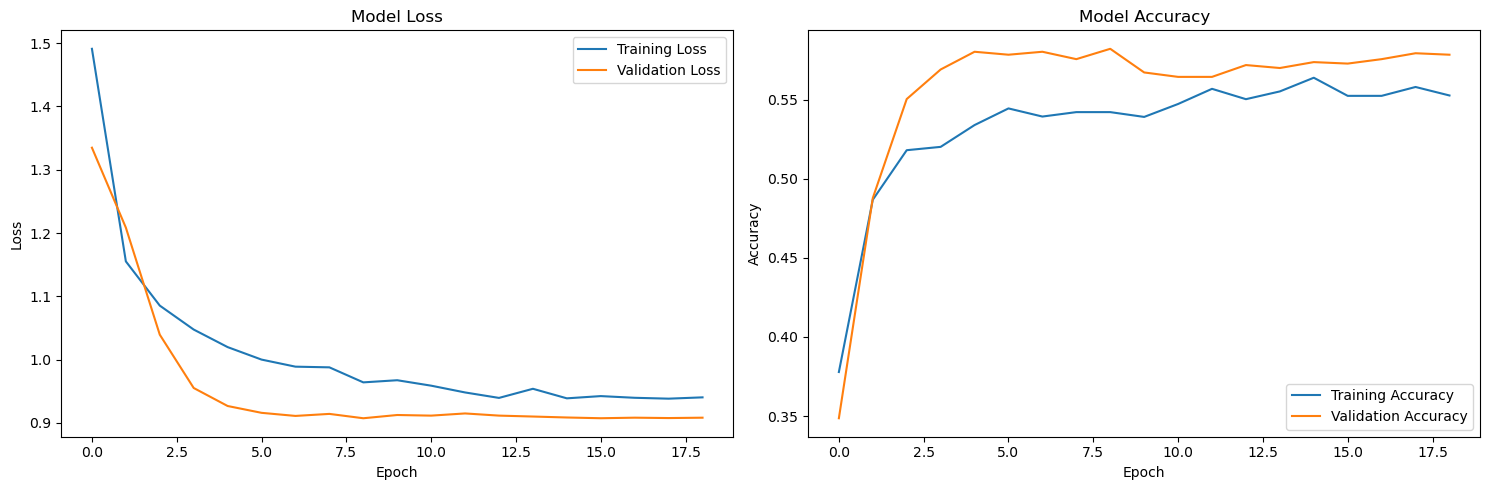

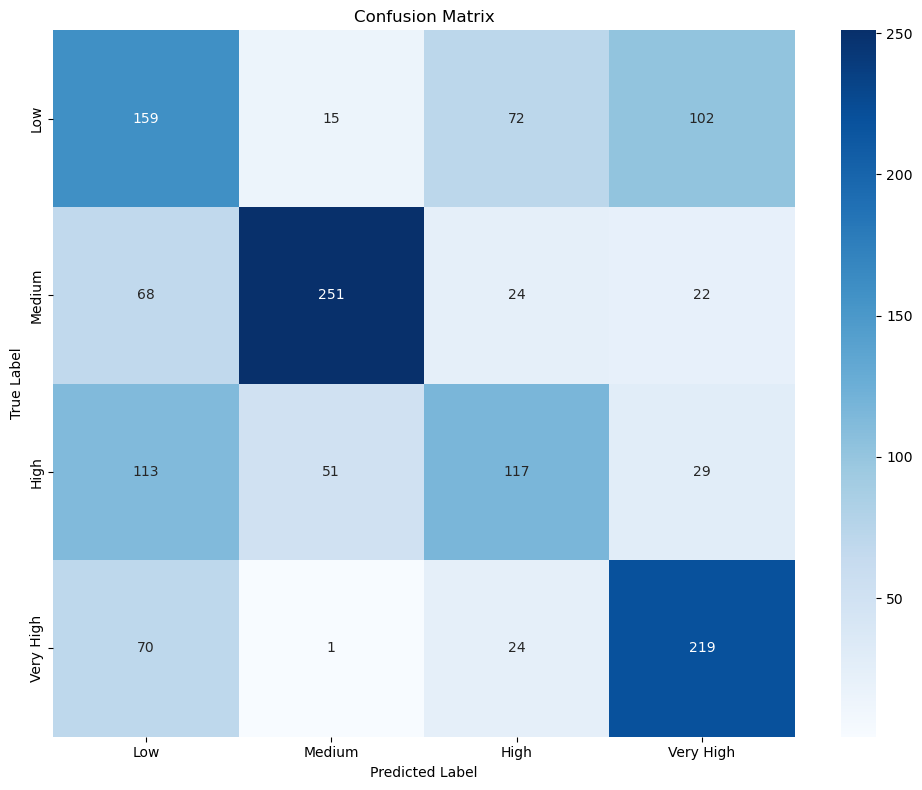

In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import seaborn as sns
import matplotlib.pyplot as plt

def categorize_salary(salary, bins=None):
    """
    Categorize salary into Low, Medium, High, Very High
    """
    if bins is None:
        # Calculate quantile-based bins
        bins = [
            float('-inf'),
            np.percentile(salary, 25),
            np.percentile(salary, 50),
            np.percentile(salary, 75),
            float('inf')
        ]
    
    categories = pd.cut(
        salary,
        bins=bins,
        labels=['Low', 'Medium', 'High', 'Very High']
    )
    return categories

def prepare_data(df):
    """
    Prepare features and target for classification
    """
    # Categorize salary
    df['Salary_Category'] = categorize_salary(df['Salary'])
    
    # Encode features (Job Title and Country)
    feature_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X = feature_encoder.fit_transform(df[['Job Title', 'Country']])
    
    # Encode target
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df['Salary_Category'])
    
    # Convert to categorical format for neural network
    y = tf.keras.utils.to_categorical(y)
    
    return X, y, feature_encoder, label_encoder

def build_model(input_dim, num_classes):
    """
    Build neural network for classification
    """
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.1),
        
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def train_model(model, X_train, y_train):
    """
    Train the model with callbacks
    """
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.00001
    )
    
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    return history

def plot_training_history(history):
    """
    Plot training metrics
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    ax1.plot(history.history['loss'], label='Training Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    # Accuracy plot
    ax2.plot(history.history['accuracy'], label='Training Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, classes):
    """
    Plot confusion matrix
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def print_distribution(df):
    """
    Print salary category distribution
    """
    dist = df['Salary_Category'].value_counts()
    total = len(df)
    print("\nSalary Category Distribution:")
    for category, count in dist.items():
        percentage = (count / total) * 100
        print(f"{category}: {count} ({percentage:.1f}%)")

def main():
    # Load dataset
    df = pd.read_csv('Salary.csv')
    
    # Prepare data
    X, y, feature_encoder, label_encoder = prepare_data(df)
    
    # Print distribution
    print_distribution(df)
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Build and train model
    model = build_model(X_train.shape[1], y_train.shape[1])
    history = train_model(model, X_train, y_train)
    
    # Evaluate model
    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)
    
    # Print classification report
    class_names = ['Low', 'Medium', 'High', 'Very High']
    print("\nClassification Report:")
    print(classification_report(y_test_classes, y_pred, 
                              target_names=class_names))
    
    # Plot results
    plot_training_history(history)
    plot_confusion_matrix(y_test_classes, y_pred, class_names)

if __name__ == "__main__":
    main()

Epoch 1/50


c:\Users\lenov\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7995 - mae: 0.7567 - val_loss: 0.4452 - val_mae: 0.5241
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4767 - mae: 0.5515 - val_loss: 0.4319 - val_mae: 0.5131
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4460 - mae: 0.5311 - val_loss: 0.4298 - val_mae: 0.5194
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4383 - mae: 0.5266 - val_loss: 0.4282 - val_mae: 0.5194
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4292 - mae: 0.5193 - val_loss: 0.4227 - val_mae: 0.5072
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4203 - mae: 0.5134 - val_loss: 0.4289 - val_mae: 0.5167
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4204 - mae: 0.5111 - val_loss: 0.4274 - val_mae: 0.5173
Epoch 8/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4211 - mae: 0.5091 - val_loss: 0.4224 - val_mae: 0.5080
Epoch 9/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4285 

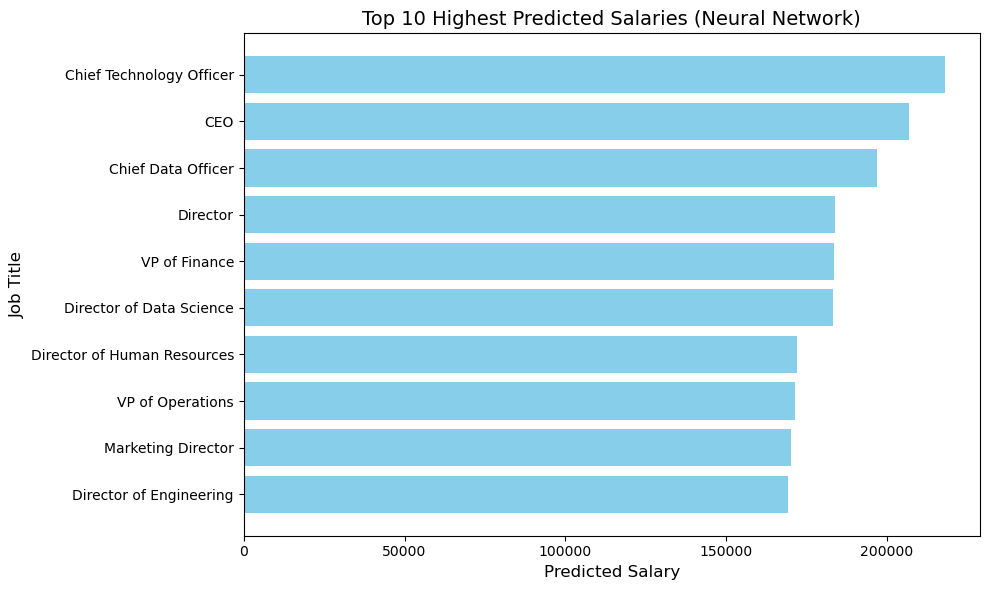

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load the dataset
file_name = 'Salary.csv'
df = pd.read_csv(file_name)

# Features (Job Title and Country) and Target (Salary)
X = df[['Job Title']]  # Focus only on Job Title
y = df['Salary']

# Encode categorical features
encoder = OneHotEncoder(drop='first')
X_encoded = encoder.fit_transform(X).toarray()

# Scale the target variable
scaler = StandardScaler()
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_scaled, test_size=0.2, random_state=42)

# Build the neural network
model = Sequential([
    Dense(128, activation='relu', input_dim=X_encoded.shape[1]),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Generate predictions for all job titles
unique_job_titles = df['Job Title'].unique()

predictions = []
for job in unique_job_titles:
    input_data = pd.DataFrame({'Job Title': [job]})
    input_encoded = encoder.transform(input_data).toarray()
    predicted_salary_scaled = model.predict(input_encoded)[0][0]
    predicted_salary = scaler.inverse_transform([[predicted_salary_scaled]])[0][0]
    predictions.append({'Job Title': job, 'Predicted Salary': predicted_salary})

# Convert predictions to a DataFrame
predictions_df = pd.DataFrame(predictions)

# Get the top 10 highest salaries
top_10_salaries = predictions_df.sort_values(by='Predicted Salary', ascending=False).head(10)

# Display the top 10 salaries
print("Top 10 Highest Predicted Salaries:")
print(top_10_salaries)

# Plot the top 10 highest salaries
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_10_salaries['Job Title'], top_10_salaries['Predicted Salary'], color='skyblue')
plt.xlabel('Predicted Salary', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.title('Top 10 Highest Predicted Salaries (Neural Network)', fontsize=14)
plt.gca().invert_yaxis()  # Invert y-axis for better alignment
plt.tight_layout()
plt.show()


10 Lowest Predicted Salaries:
                           Job Title  Predicted Salary
109      Business Operations Analyst      10387.665393
126                     Receptionist      27344.017054
128                  Delivery Driver      31399.087308
124           Juniour HR Coordinator      31457.274511
3                    Sales Associate      34404.200818
58   Customer Service Representative      35267.504040
90       Customer Support Specialist      35523.649852
18                  Data Entry Clerk      35541.904167
96                    HR Coordinator      39858.854605
37              Customer Success Rep      40714.125929


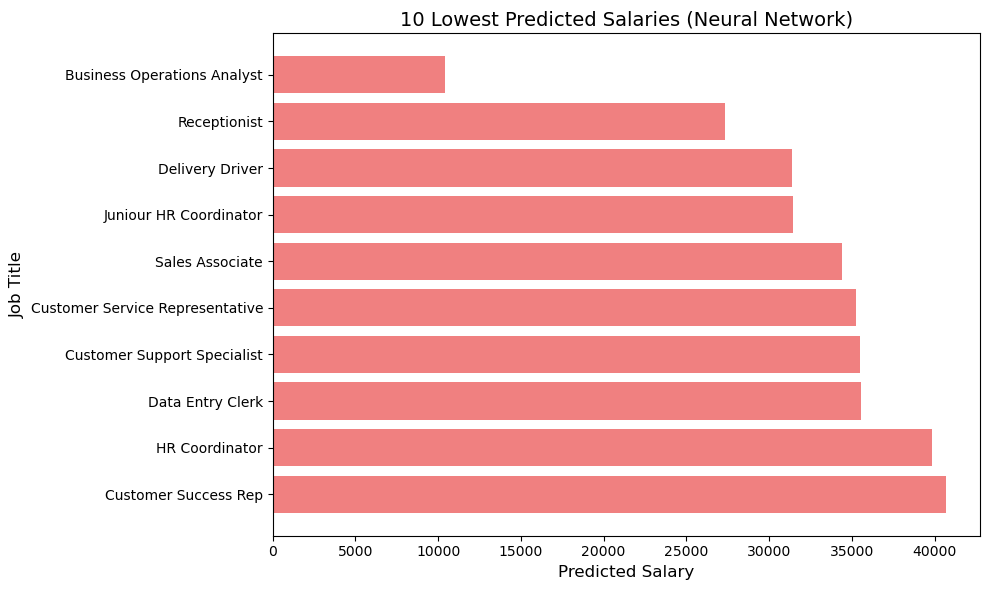

In [17]:
# Get the 10 lowest predicted salaries
lowest_10_salaries = predictions_df.sort_values(by='Predicted Salary', ascending=True).head(10)

# Display the 10 lowest salaries
print("10 Lowest Predicted Salaries:")
print(lowest_10_salaries)

# Plot the 10 lowest salaries
plt.figure(figsize=(10, 6))
plt.barh(lowest_10_salaries['Job Title'], lowest_10_salaries['Predicted Salary'], color='lightcoral')
plt.xlabel('Predicted Salary', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.title('10 Lowest Predicted Salaries (Neural Network)', fontsize=14)
plt.gca().invert_yaxis()  # Invert y-axis for better alignment
plt.tight_layout()
plt.show()


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on the test set
nn_y_pred = model.predict(X_test)  # Assuming `model` is your trained NN model

# Inverse transform the predicted salaries (if you scaled the target)
nn_y_pred = scaler.inverse_transform(nn_y_pred)

# Calculate regression metrics
nn_mae = mean_absolute_error(y_test, nn_y_pred)
nn_mse = mean_squared_error(y_test, nn_y_pred)
nn_r2 = r2_score(y_test, nn_y_pred)

# Print results
print(f"Neural Network Mean Absolute Error (MAE): {nn_mae:.2f}")
print(f"Neural Network Mean Squared Error (MSE): {nn_mse:.2f}")
print(f"Neural Network R² Score: {nn_r2:.2f}")


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Neural Network Mean Absolute Error (MAE): 115587.20
Neural Network Mean Squared Error (MSE): 15033902530.48
Neural Network R² Score: -15083840451.22


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load the dataset
file_name = 'Salary.csv'
df = pd.read_csv(file_name)

# Features (Job Title) and Target (Salary)
X = df[['Job Title']]  # Only use 'Job Title' for classification
y = df['Salary']

# Encode categorical features
encoder = OneHotEncoder(drop='first')
X_encoded = encoder.fit_transform(X).toarray()

# Bin the salary into categories
k_bins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')  # 4 categories: Low, Medium, High, Very High
y_binned = k_bins.fit_transform(y.values.reshape(-1, 1)).ravel()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_binned, test_size=0.2, random_state=42)

# Convert target labels to one-hot encoding
y_train_onehot = np.eye(4)[y_train.astype(int)]  # 4 classes
y_test_onehot = np.eye(4)[y_test.astype(int)]

# Build the neural network
model = Sequential([
    Dense(128, activation='relu', input_dim=X_encoded.shape[1]),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')  # 4 output nodes for 4 classes
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train_onehot, epochs=50, batch_size=32, validation_data=(X_test, y_test_onehot), verbose=1)

# Make predictions on the test set
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

# Classification report
class_labels = ['Low', 'Medium', 'High', 'Very High']
report = classification_report(y_test, y_pred, target_names=class_labels)
print("\nClassification Report:")
print(report)


Epoch 1/50


c:\Users\lenov\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:248: FutureWarning: In version 1.5 onwards, subsample=200_000 will be used by default. Set subsample explicitly to silence this warning in the mean time. Set subsample=None to disable subsampling explicitly.
  warnings.warn(
c:\Users\lenov\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4251 - loss: 1.2730 - val_accuracy: 0.5654 - val_loss: 0.9295
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5821 - loss: 0.9321 - val_accuracy: 0.6066 - val_loss: 0.8803
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5983 - loss: 0.9068 - val_accuracy: 0.6013 - val_loss: 0.8638
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6131 - loss: 0.8794 - val_accuracy: 0.6096 - val_loss: 0.8535
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6146 - loss: 0.8662 - val_accuracy: 0.6111 - val_loss: 0.8480
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6156 - loss: 0.8554 - val_accuracy: 0.6073 - val_loss: 0.8513
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6055 - loss: 0.8471 - val_accuracy: 0.6133 - val_loss: 0.8458
Epoch 8/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6195 - loss: 0.8358 - val_accuracy: 0.6133 - val_

In [29]:
pip install tensorflow



     ---------------------------------------- 0.0/48.7 kB ? eta -:--:--
     ---------------------------------------- 48.7/48.7 kB 2.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/390.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/390.3 MB 4.1 MB/s eta 0:01:36
   ---------------------------------------- 0.3/390.3 MB 3.2 MB/s eta 0:02:04
   ---------------------------------------- 0.5/390.3 MB 3.5 MB/s eta 0:01:51
   ---------------------------------------- 0.7/390.3 MB 3.9 MB/s eta 0:01:41
   ---------------------------------------- 1.0/390.3 MB 4.5 MB/s eta 0:01:28
   ---------------------------------------- 1.1/390.3 MB 4.5 MB/s eta 0:01:28
   ---------------------------------------- 1.2/390.3 MB 4.0 MB/s eta 0:01:37
   ---------------------------------------- 1.3/390.3 MB 3.6 MB/s eta 0:01:47
   ---------------------------------------- 1.3/390.3 MB 3.6 MB/s eta 0:01:47
   ---------------------------------------- 1.3/390.3 MB 3.6 MB/s eta 0:01

In [2]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time

# Configure Selenium WebDriver
options = webdriver.ChromeOptions()
options.add_argument("--headless")  # Run in headless mode
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

# Function to scrape a single page of results
def scrape_jobs(page_url):
    driver.get(page_url)
    wait = WebDriverWait(driver, 10)
    wait.until(EC.presence_of_all_elements_located((By.CLASS_NAME, "job_seen_beacon")))

    jobs = driver.find_elements(By.CLASS_NAME, "job_seen_beacon")
    data = []

    for job in jobs:
        try:
            title = job.find_element(By.CLASS_NAME, "jobTitle").text
        except:
            title = "N/A"

        try:
            company = job.find_element(By.CLASS_NAME, "companyName").text
        except:
            company = "N/A"

        try:
            location = job.find_element(By.CLASS_NAME, "companyLocation").text
        except:
            location = "N/A"

        data.append({"Job Title": title, "Company": company, "Location": location})

    return data

# Start scraping
base_url = "https://www.indeed.com/jobs?q=Data+Scientist&start="  # Example URL for Data Scientist jobs
all_jobs = []
max_pages = 500  # Adjust based on the number of results per page (e.g., 10 jobs/page)

for page in range(0, max_pages):
    page_url = f"{base_url}{page * 10}"  # Each page increments by 10
    try:
        jobs = scrape_jobs(page_url)
        if not jobs:  # Stop if no jobs found
            break
        all_jobs.extend(jobs)
        print(f"Scraped page {page + 1}")
    except Exception as e:
        print(f"Error on page {page + 1}: {e}")
        continue

    time.sleep(2)  # Be courteous to the server

# Save data to CSV
if all_jobs:
    df = pd.DataFrame(all_jobs)
    df.to_csv("indeed_jobs.csv", index=False)
    print("Scraping complete! Data saved to indeed_jobs.csv")
else:
    print("No data scraped.")

# Close the driver
driver.quit()


KeyboardInterrupt: 

In [6]:
import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options



In [ ]:
# Define the base LinkedIn URL
base_url = "https://www.linkedin.com/jobs/search?keywords=Data%20Scientist&location=Worldwide"

# Open LinkedIn and search for jobs
driver.get(base_url)

# Add login functionality if necessary (you need to log in to access more job posts)
# (skip this if you're already logged in)

# For example:
# login_button = driver.find_element(By.XPATH, '//*[@id="session_key"]')
# login_button.send_keys('your_email')
# password_button = driver.find_element(By.XPATH, '//*[@id="session_password"]')
# password_button.send_keys('your_password')
# login_button = driver.find_element(By.XPATH, '//*[@id="login-submit"]')
# login_button.click()

# Add a delay to let the page load
time.sleep(5)

# Define lists to store scraped data
job_titles = []
company_names = []
locations = []

# Scroll and scrape data
for page_num in range(10):  # Modify this to get 5000 results, this example is set for 10 pages
    job_cards = driver.find_elements(By.CSS_SELECTOR, '.job-card-container')
    
    for job in job_cards:
        try:
            title = job.find_element(By.CSS_SELECTOR, '.job-card-list__title').text
            company = job.find_element(By.CSS_SELECTOR, '.job-card-container__company-name').text
            location = job.find_element(By.CSS_SELECTOR, '.job-card-container__metadata-item').text

            job_titles.append(title)
            company_names.append(company)
            locations.append(location)
        except Exception as e:
            print(f"Error scraping job card: {e}")
    
    # Scroll down to load more jobs
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(3)  # Let the page load

    # Move to next page (you can modify this part to navigate through pages)
    try:
        next_button = driver.find_element(By.XPATH, '//button[contains(@aria-label, "Next")]')
        next_button.click()
        time.sleep(3)
    except:
        print("No more pages to scrape.")
        break

# Save the scraped data to a CSV file
df = pd.DataFrame({
    "Job Title": job_titles,
    "Company": company_names,
    "Location": locations
})

# Save to CSV
df.to_csv('linkedin_jobs.csv', index=False)

print("Scraping complete! Data saved to linkedin_jobs.csv")
